# Positional Precision — DeepWings "metric 2"

This notebook reproduces the **positional precision** score from DeepWings©
(Rodrigues et al., *Big Data and Cognitive Computing* 6(3):70, 2022 —
https://doi.org/10.3390/bdcc6030070), reported there as
*"an average positional precision of 0.943 resemblance to manually annotated landmarks."*

`19_new_statistics.ipynb` measures the **mean / median Euclidean pixel error** between
predicted and ground-truth landmarks. This notebook measures a different, complementary
quantity:

> For each wing, the predicted shape and its manual ground-truth shape are superimposed into a
> common **Procrustes space** (translation, scale and rotation removed). Inside that space we
> take every **pairwise inter-landmark Euclidean distance** for both shapes and compare them
> pair-by-pair as a ratio `min(d_pred, d_gt) / max(d_pred, d_gt)`. The mean of those ratios is
> the wing's precision; **1.0** means the predicted constellation is geometrically identical to
> the manual one.

Because it is built on *relative* distances after Procrustes alignment, the score is invariant
to translation, scale and rotation — it asks *"is the **shape** right?"*, whereas the pixel
error asks *"are the points in the **right place**?"*.

## 1. Load the U-Net model

Same checkpoint as `19_new_statistics.ipynb`. YOLO is not needed here — the test dataset already
holds preprocessed, cropped wing images.

In [1]:
from wings.modeling.loss import BCEDiceLoss
from wings.modeling.litnet import LitNet
from wings.config import PROCESSED_DATA_DIR, MODELS_DIR
from wings.modeling.unet import UNet
import torch

mean_coords = torch.load(
    PROCESSED_DATA_DIR / "mask_datasets" / "rectangle" / "mean_shape.pth", weights_only=False
)

checkpoint_path = MODELS_DIR / "new_unet" / "unet-final-k5.ckpt"

unet_model = UNet(in_channels=1, out_channels=1, kernel_size=5)
model = LitNet.load_from_checkpoint(
    checkpoint_path, model=unet_model, criterion=BCEDiceLoss(), strict=False
)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print("model loaded on", device)

2026-06-26 19:30:04.833 | INFO     | wings.config:<module>:44 - PROJ_ROOT path is: C:\Users\X\projects\bees
2026-06-26 19:30:06.662 | INFO     | wings.config:<module>:68 - torch.cuda.get_device_name()='NVIDIA RTX A3000 12GB Laptop GPU'
W0626 19:30:14.769000 47820 .venv\Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


model loaded on cuda


## 2. Load the test dataset

In [2]:
test_dataset = torch.load(
    PROCESSED_DATA_DIR / "mask_datasets" / "rectangle-cropped" / "test_mask_dataset_ch1_400.pth",
    weights_only=False,
)
len(test_dataset)

2172

## 3. Run inference and collect predicted vs. ground-truth landmarks

This mirrors the evaluation loop in `19_new_statistics.ipynb`: every wing is grouped by how many
raw blobs the U-Net produced (`<18`, `18`, `19`, `20`, `>20`), and `handle_coordinates`
reconstructs a canonical **19-point** shape with a consistent landmark ordering, so that
predicted point *i* corresponds to ground-truth point *i* (required for the pairwise comparison).

In [3]:
from wings.visualizing.image_preprocess import final_coords
from wings.gpa import handle_coordinates
import numpy as np
from tqdm import tqdm

original_labels = [[] for _ in range(5)]
predicted_labels = [[] for _ in range(5)]
points_indices = [[] for _ in range(5)]

model.eval()
for idx, (image, _, coords, (x_size, y_size)) in enumerate(tqdm(test_dataset, desc="Evaluating")):
    image = image.to(device).unsqueeze(0)
    with torch.no_grad():
        output = model(image)
    mask = torch.round(output).squeeze().detach().cpu().numpy()
    mask_coords = torch.tensor(final_coords(mask, x_size, y_size))
    n_points = len(mask_coords)

    if n_points < 18:
        idx_group = 0
    elif n_points == 18:
        idx_group = 1
    elif n_points == 19:
        idx_group = 2
    elif n_points == 20:
        idx_group = 3
    else:
        idx_group = 4

    reordered = handle_coordinates(mask_coords, mean_coords).cpu().numpy()
    orig = coords.view(-1, 2).cpu().numpy()

    points_indices[idx_group].append(idx)
    original_labels[idx_group].append(orig)
    predicted_labels[idx_group].append(reordered)

original_labels = [np.stack(l) if len(l) else np.empty((0, 19, 2)) for l in original_labels]
predicted_labels = [np.stack(l) if len(l) else np.empty((0, 19, 2)) for l in predicted_labels]

total_samples_num = len(test_dataset)
failed_samples_num = sum(len(points_indices[i]) for i in [0, 1, 3, 4])  # all but the 19-blob group
print(f"Total samples : {total_samples_num}")
print(f"Masks without exactly 19 blobs: {failed_samples_num}")
for i, label in enumerate(["<18", "18", "19", "20", ">20"]):
    print(f"  group {label:>3}-blobs: {predicted_labels[i].shape[0]} wings")

Evaluating: 100%|██████████| 2172/2172 [01:16<00:00, 28.54it/s]

Total samples : 2172
Masks without exactly 19 blobs: 12
  group <18-blobs: 0 wings
  group  18-blobs: 7 wings
  group  19-blobs: 2160 wings
  group  20-blobs: 4 wings
  group >20-blobs: 1 wings


## 4. The metric

Let a wing have predicted landmarks $P=\{p_1,\dots,p_{19}\}$ and manual landmarks
$G=\{g_1,\dots,g_{19}\}$ with $p_i \leftrightarrow g_i$. Both are **Procrustes-superimposed**
(centred, scaled to unit norm, predicted optimally rotated onto the ground truth). Writing
$d^{P}_{ij}=\lVert p_i-p_j\rVert$ and $d^{G}_{ij}=\lVert g_i-g_j\rVert$ for the Procrustes-space
inter-landmark distances, the positional precision of the wing is

$$
\text{precision} \;=\; \frac{1}{19\cdot 18}\sum_{i\neq j}
\frac{\min\!\left(d^{P}_{ij},\,d^{G}_{ij}\right)}{\max\!\left(d^{P}_{ij},\,d^{G}_{ij}\right)}.
$$

There are $19\times 19-19 = 342$ ordered off-diagonal pairs (the 19 self-distances are dropped).
The **per-landmark** precision averages the 18 ratios involving that landmark, and the
**dataset** score is the mean over all wings.

This is exactly DeepWings' `compareShape` / `difference` routine, where
`difference(a, b) = min(a, b) / max(a, b)` and the maximum precision of `1` is reached when the
two shapes are identical (every distance ratio equals 1).

In [4]:
from scipy.spatial import procrustes
from scipy.spatial.distance import pdist, squareform


def wing_positional_precision(gt, pred):
    """DeepWings 'metric 2' positional precision for a single wing.

    Parameters
    ----------
    gt, pred : (19, 2) arrays of corresponding landmarks (image coordinates).

    Returns
    -------
    wing_precision : float        mean min/max distance-ratio over all 342 landmark pairs.
    per_landmark   : (19,) float  mean ratio over the 18 partners of each landmark.
    """
    # Procrustes superimposition: centre + unit-scale both shapes, rotate pred onto gt.
    mtx_gt, mtx_pred, _ = procrustes(np.asarray(gt, float), np.asarray(pred, float))

    d_gt = squareform(pdist(mtx_gt))      # (19, 19) inter-landmark distances, 0 on diagonal
    d_pred = squareform(pdist(mtx_pred))

    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = np.minimum(d_gt, d_pred) / np.maximum(d_gt, d_pred)
    np.fill_diagonal(ratio, np.nan)       # drop the 19 self-distances (0 / 0)

    return np.nanmean(ratio), np.nanmean(ratio, axis=1)


def group_positional_precision(gts, preds):
    """Vectorise `wing_positional_precision` over (N, 19, 2) arrays.

    Returns wing_precisions (N,) and per_landmark (N, 19); degenerate shapes -> nan.
    """
    n = len(gts)
    wing = np.full(n, np.nan)
    per_lm = np.full((n, 19), np.nan)
    for k in range(n):
        try:
            wing[k], per_lm[k] = wing_positional_precision(gts[k], preds[k])
        except ValueError:
            # scipy.procrustes rejects all-identical / zero-norm shapes; leave as nan.
            pass
    return wing, per_lm

## 5. Results — precision per detection group and overall

In [5]:
group_names = ["<18", "18", "19", "20", ">20"]
wing_prec_by_group = []
per_lm_by_group = []

for g in range(5):
    if predicted_labels[g].shape[0] == 0:
        wing_prec_by_group.append(np.empty(0))
        per_lm_by_group.append(np.empty((0, 19)))
        continue
    wp, plm = group_positional_precision(original_labels[g], predicted_labels[g])
    wing_prec_by_group.append(wp)
    per_lm_by_group.append(plm)

print(f"{'raw blobs':>10} | {'wings':>6} | {'mean prec':>9} | {'median prec':>11}")
print("-" * 46)
for g in range(5):
    wp = wing_prec_by_group[g]
    if wp.size == 0:
        print(f"{group_names[g]:>10} | {0:>6} |    n/a    |     n/a")
        continue
    print(f"{group_names[g]:>10} | {wp.size:>6} | {np.nanmean(wp):>9.4f} | {np.nanmedian(wp):>11.4f}")

all_wp = np.concatenate([wp for wp in wing_prec_by_group if wp.size])
print("-" * 46)
print(f"{'ALL':>10} | {all_wp.size:>6} | {np.nanmean(all_wp):>9.4f} | {np.nanmedian(all_wp):>11.4f}")

# Headline numbers
clean = wing_prec_by_group[2]  # wings where the U-Net produced exactly 19 blobs
print()
if clean.size:
    print(f"Positional precision on clean 19-blob detections : {np.nanmean(clean):.4f}")
print(f"Positional precision over ALL wings              : {np.nanmean(all_wp):.4f}")
print("(DeepWings reference value: 0.943)")

 raw blobs |  wings | mean prec | median prec
----------------------------------------------
       <18 |      0 |    n/a    |     n/a
        18 |      7 |    0.9911 |      0.9914
        19 |   2160 |    0.9939 |      0.9940
        20 |      4 |    0.9939 |      0.9937
       >20 |      1 |    0.9925 |      0.9925
----------------------------------------------
       ALL |   2172 |    0.9938 |      0.9940

Positional precision on clean 19-blob detections : 0.9939
Positional precision over ALL wings              : 0.9938
(DeepWings reference value: 0.943)


## 6. Per-landmark positional precision

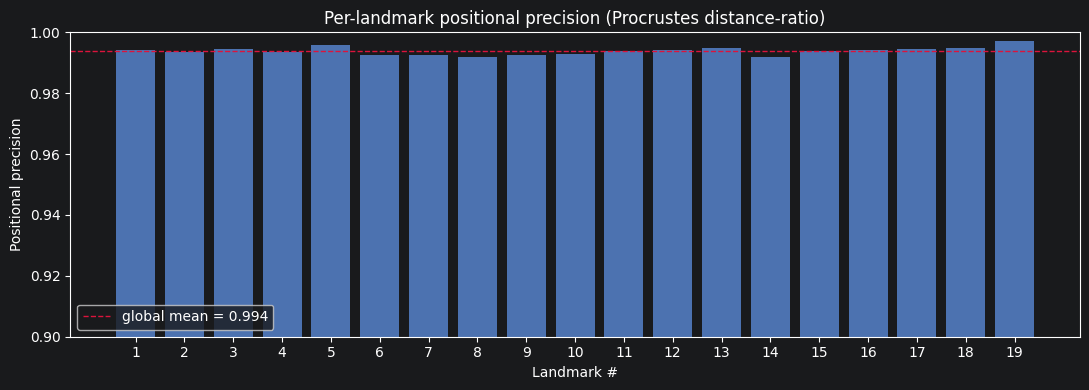

landmark  1: 0.9941
landmark  2: 0.9935
landmark  3: 0.9945
landmark  4: 0.9934
landmark  5: 0.9958
landmark  6: 0.9924
landmark  7: 0.9926
landmark  8: 0.9920
landmark  9: 0.9925
landmark 10: 0.9928
landmark 11: 0.9937
landmark 12: 0.9941
landmark 13: 0.9948
landmark 14: 0.9920
landmark 15: 0.9938
landmark 16: 0.9941
landmark 17: 0.9946
landmark 18: 0.9950
landmark 19: 0.9973


In [6]:
import matplotlib.pyplot as plt

# Mean per-landmark precision over every wing.
all_per_lm = np.concatenate([plm for plm in per_lm_by_group if plm.shape[0]], axis=0)
per_landmark_mean = np.nanmean(all_per_lm, axis=0)
global_mean = np.nanmean(all_wp)

plt.figure(figsize=(11, 4))
plt.bar(np.arange(1, 20), per_landmark_mean, color="#4C72B0")
plt.axhline(global_mean, color="crimson", ls="--", lw=1, label=f"global mean = {global_mean:.3f}")
lo = np.nanmin(per_landmark_mean)
plt.ylim(max(0.0, min(0.9, lo - 0.02)), 1.0)
plt.xticks(np.arange(1, 20))
plt.xlabel("Landmark #")
plt.ylabel("Positional precision")
plt.title("Per-landmark positional precision (Procrustes distance-ratio)")
plt.legend()
plt.tight_layout()
plt.show()

for i, v in enumerate(per_landmark_mean, start=1):
    print(f"landmark {i:>2}: {v:.4f}")

## 7. Positional precision vs. pixel error (context)

The two metrics answer different questions. The cell below reports both on the **same** clean
19-blob detections so the contrast is concrete: the Procrustes distance-ratio precision is
scale-free and bounded in `[0, 1]` (higher is better), while the Euclidean pixel error is in raw
image pixels (lower is better) and is the metric used in `19_new_statistics.ipynb`.

In [7]:
g = 2  # clean 19-blob detections
if predicted_labels[g].shape[0]:
    pix_err = np.linalg.norm(predicted_labels[g] - original_labels[g], axis=2)  # (N, 19) per-point
    print(f"Clean 19-blob detections: {predicted_labels[g].shape[0]} wings\n")
    print(f"  positional precision (Procrustes, scale-free) : {np.nanmean(wing_prec_by_group[g]):.4f}   (1.0 = perfect)")
    print(f"  mean   Euclidean pixel error                  : {pix_err.mean():.4f} px")
    print(f"  median Euclidean pixel error                  : {np.median(pix_err):.4f} px")
else:
    print("No clean 19-blob detections available.")

Clean 19-blob detections: 2160 wings

  positional precision (Procrustes, scale-free) : 0.9939   (1.0 = perfect)
  mean   Euclidean pixel error                  : 1.0599 px
  median Euclidean pixel error                  : 0.9683 px
